Лабораторна робота 2. Соловей, 3-12

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

headers = {
    "User-Agent": "Mozilla/5.0 (compatible; StudentDataAnalysis/1.0)"
}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))

# Знаходимо потрібну таблицю
df = None

for table in tables:
    columns_text = " ".join(map(str, table.columns))
    if ("IMF" in columns_text and
        "World Bank" in columns_text and
        "United Nations" in columns_text):
        df = table.copy()
        break

if df is None:
    raise ValueError("Не вдалося знайти таблицю з даними IMF, World Bank та United Nations.")

df.columns = [
    "Country/Territory",
    "IMF (2026)",
    "World Bank (2025)",
    "United Nations (2024)"
]

df.head()


,Country/Territory,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [2]:
print("Перші 5 рядків датасета:")
df.head()


Перші 5 рядків датасета:


,Country/Territory,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [3]:
print("Розмір датасета:", df.shape)


Розмір датасета: (222, 4)


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [4]:
# Залишаємо потрібні стовпці
df = df[[
    "Country/Territory",
    "IMF (2026)",
    "World Bank (2025)",
    "United Nations (2024)"
]].copy()

# Видаляємо загальний рядок World
df = df[df["Country/Territory"] != "World"].reset_index(drop=True)

df.head()


,Country/Territory,IMF (2026),World Bank (2025),United Nations (2024)
0,United States,32383920,30769700,29298000
1,China[n 1],20851593,19498039,18743802
2,Germany,5452858,5050923,4659929
3,Japan,4379253,4435163,4026211
4,United Kingdom,4264794,4002588,3685881


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [5]:
# Замінюємо пропуски на NaN
df = df.replace(r"^—.*$", np.nan, regex=True)

df.isna().sum()


,0
Country/Territory,0
IMF (2026),24
World Bank (2025),7
United Nations (2024),9


In [6]:
# Перетворюємо дані у числовий формат
numeric_cols = ["IMF (2026)", "World Bank (2025)", "United Nations (2024)"]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes


,0
Country/Territory,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [7]:
# Перевіряємо пропуски
df.isna().sum()


,0
Country/Territory,0
IMF (2026),24
World Bank (2025),7
United Nations (2024),9


In [8]:
# Заповнюємо пропуски середнім значенням
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

df.isna().sum()


,0
Country/Territory,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [9]:
print("Загальна кількість пропущених значень:", df.isna().sum().sum())


Загальна кількість пропущених значень: 0


5. Ще раз вивести датасет

In [10]:
df


,Country/Territory,IMF (2026),World Bank (2025),United Nations (2024)
0,United States,3.238392e+07,3.076970e+07,29298000.0
1,China[n 1],2.085159e+07,1.949804e+07,18743802.0
2,Germany,5.452858e+06,5.050923e+06,4659929.0
3,Japan,4.379253e+06,4.435163e+06,4026211.0
4,United Kingdom,4.264794e+06,4.002588e+06,3685881.0
...,...,...,...,...
216,Palau,3.770000e+02,3.450000e+02,310.0
217,Marshall Islands,3.420000e+02,3.080000e+02,281.0
218,Nauru,1.960000e+02,1.760000e+02,187.0
219,Montserrat,6.412000e+05,5.482661e+05,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [11]:
print("Кількість дублікатів:", df.duplicated().sum())


Кількість дублікатів: 0


In [12]:
# Видаляємо дублікати
df = df.drop_duplicates().copy()


In [13]:
print("Кількість дублікатів після очищення:", df.duplicated().sum())
print("Розмір датасета після очищення:", df.shape)


Кількість дублікатів після очищення: 0
Розмір датасета після очищення: (221, 4)


7.	Вивести описову статистику датасету describe()

In [14]:
df.describe()


,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.412000e+05,5.482661e+05,5.224912e+05
std,2.668734e+06,2.528406e+06,2.410079e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.733600e+04,9.194000e+03,8.840000e+03
50%,8.383200e+04,4.549000e+04,4.276500e+04
75%,5.799960e+05,3.062390e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?
**Відповідь:** після виконання коду нижче країни з найбільшою різницею будуть показані першими у таблиці.


In [15]:
# Різниця між показниками
df["Difference IMF-WB"] = abs(df["IMF (2026)"] - df["World Bank (2025)"])

difference = df[[
    "Country/Territory",
    "IMF (2026)",
    "World Bank (2025)",
    "Difference IMF-WB"
]].sort_values("Difference IMF-WB", ascending=False)

difference.head(10)


,Country/Territory,IMF (2026),World Bank (2025),Difference IMF-WB
0,United States,3.238392e+07,30769700.0,1.614220e+06
1,China[n 1],2.085159e+07,19498039.0,1.353554e+06
211,Saint Martin,6.412000e+05,649.0,6.405510e+05
208,American Samoa,6.412000e+05,871.0,6.403290e+05
207,Northern Mariana Islands,6.412000e+05,1096.0,6.401040e+05
200,Turks and Caicos Islands,6.412000e+05,1745.0,6.394550e+05
196,Sint Maarten,6.412000e+05,1888.0,6.393120e+05
183,Greenland,6.412000e+05,3327.0,6.378730e+05
181,Curaçao,6.412000e+05,3561.0,6.376390e+05
179,Faroe Islands,6.412000e+05,4053.0,6.371470e+05


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?
**Відповідь:** код нижче обчислює матрицю кореляцій і окремо виводить пару з найвищим коефіцієнтом.


In [16]:
correlation = df[numeric_cols].corr()
correlation


,IMF (2026),World Bank (2025),United Nations (2024)
IMF (2026),1.000000,0.997809,0.998046
World Bank (2025),0.997809,1.000000,0.998378
United Nations (2024),0.998046,0.998378,1.000000


In [17]:
# Найвища кореляція
corr_pairs = correlation.where(
    np.triu(np.ones(correlation.shape), k=1).astype(bool)
).stack().sort_values(ascending=False)

print("Кореляції між парами показників:")
print(corr_pairs)

print("\nНайвища кореляція:")
print(corr_pairs.index[0], "=", round(corr_pairs.iloc[0], 4))


Кореляції між парами показників:
World Bank (2025)  United Nations (2024)    0.998378
IMF (2026)         United Nations (2024)    0.998046
                   World Bank (2025)        0.997809
dtype: float64

Найвища кореляція:
('World Bank (2025)', 'United Nations (2024)') = 0.9984


Обчислити середнє значення за стовпцями

In [18]:
mean_values = df[numeric_cols].mean()
mean_values


,0
IMF (2026),641200.030457
World Bank (2025),548266.060748
United Nations (2024),522491.207547


In [19]:
print("Середнє значення IMF (2026):", round(df["IMF (2026)"].mean(), 2))


Середнє значення IMF (2026): 641200.03


In [20]:
print("Середнє значення World Bank (2025):", round(df["World Bank (2025)"].mean(), 2))
print("Середнє значення United Nations (2024):", round(df["United Nations (2024)"].mean(), 2))


Середнє значення World Bank (2025): 548266.06
Середнє значення United Nations (2024): 522491.21


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?
**Відповідь:** країна з найвищою варіативністю буде першою у відсортованій таблиці `variability`.


In [21]:
# Стандартне відхилення
df["Std"] = df[numeric_cols].std(axis=1)

variability = df[["Country/Territory", "Std"]].sort_values("Std", ascending=False)

variability.head(10)


,Country/Territory,Std
0,United States,1.543508e+06
1,China[n 1],1.068002e+06
2,Germany,3.964771e+05
200,Turks and Caicos Islands,3.691861e+05
196,Sint Maarten,3.691699e+05
183,Greenland,3.682360e+05
181,Curaçao,3.681411e+05
170,French Polynesia,3.665461e+05
165,Cayman Islands,3.657451e+05
160,New Caledonia,3.652612e+05


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

Для кожного джерела знайдемо країни/території з найбільшим і найменшим показником.


In [22]:
for col in numeric_cols:
    max_index = df[col].idxmax()
    min_index = df[col].idxmin()

    print(col)
    print("Найвищий показник:",
          df.loc[max_index, "Country/Territory"],
          "-", df.loc[max_index, col])
    print("Найнижчий показник:",
          df.loc[min_index, "Country/Territory"],
          "-", df.loc[min_index, col])
    print()


IMF (2026)
Найвищий показник: United States - 32383920.0
Найнижчий показник: Tuvalu - 65.0

World Bank (2025)
Найвищий показник: United States - 30769700.0
Найнижчий показник: Tuvalu - 57.0

United Nations (2024)
Найвищий показник: United States - 29298000.0
Найнижчий показник: Tuvalu - 56.0



13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

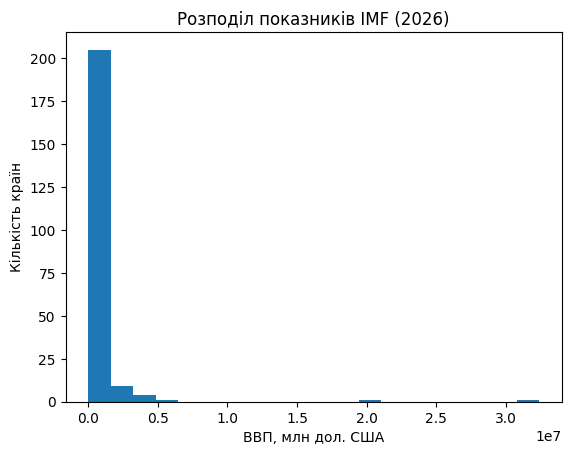

,Country/Territory,IMF (2026)
0,United States,32383920.0
1,China[n 1],20851593.0
2,Germany,5452858.0
3,Japan,4379253.0
4,United Kingdom,4264794.0
5,India,4153191.0
6,France,3596094.0
7,Italy,2738164.0
8,Russia,2656452.0
9,Brazil,2635912.0


In [23]:
df["IMF (2026)"].plot(
    kind="hist",
    bins=20,
    title="Розподіл показників IMF (2026)"
)
plt.xlabel("ВВП, млн дол. США")
plt.ylabel("Кількість країн")
plt.show()

# Найбільші значення, які найбільше виділяються на розподілі
df.nlargest(10, "IMF (2026)")[["Country/Territory", "IMF (2026)"]]


**Висновок:** розподіл має правосторонню асиметрію: більшість країн мають відносно менші значення ВВП, а невелика кількість найбільших економік суттєво виділяється. Конкретні країни, що мають найбільші значення, виводяться під графіком.


14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?
**Відповідь:** частки обчислюються у відсотках. Порівняння трьох нових стовпців показує, як змінюється внесок кожної країни між показниками різних джерел/років.


In [24]:
# Обчислюємо частки
share_cols = []

for col in numeric_cols:
    share_col = f"Share {col}"
    df[share_col] = df[col] / df[col].sum() * 100
    share_cols.append(share_col)

shares = df[["Country/Territory"] + share_cols].copy()
shares.head(10)


,Country/Territory,Share IMF (2026),Share World Bank (2025),Share United Nations (2024)
0,United States,22.853021,25.394498,25.372702
1,China[n 1],14.714768,16.091899,16.232538
2,Germany,3.848029,4.168570,4.035599
3,Japan,3.090397,3.660378,3.486786
4,United Kingdom,3.009624,3.303370,3.192053
5,India,2.930867,3.264976,3.422729
6,France,2.537729,2.778250,2.737012
7,Italy,1.932296,2.105822,2.061846
8,Russia,1.874633,2.113871,1.882199
9,Brazil,1.860138,1.881638,1.892969


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

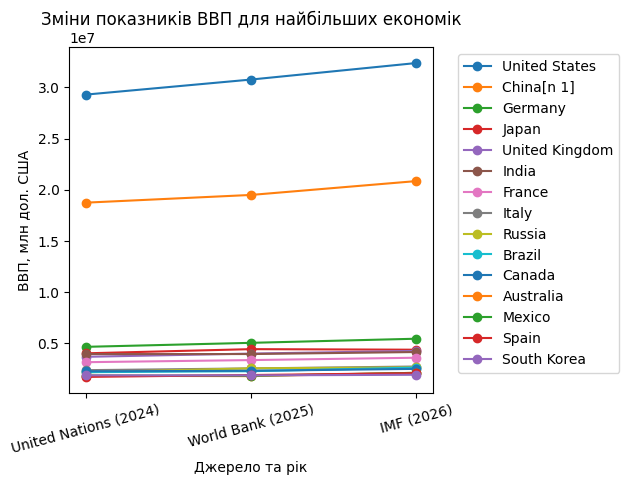

Стабільне зростання:
['United States', 'China[n 1]', 'Germany', 'United Kingdom', 'India', 'France', 'Italy', 'Russia', 'Brazil', 'Canada', 'Spain', 'Turkey', 'Indonesia', 'Netherlands', 'Saudi Arabia', 'Switzerland', 'Poland', 'Taiwan[n 3]', 'Ireland', 'Belgium', 'Sweden', 'Israel', 'Argentina', 'Singapore', 'Austria', 'Norway', 'Thailand', 'Colombia', 'Vietnam', 'Malaysia', 'Philippines', 'Bangladesh', 'Denmark', 'Romania', 'South Africa', 'Hong Kong[n 4]', 'Czech Republic', 'Egypt', 'Chile', 'Pakistan', 'Peru', 'Portugal', 'Nigeria', 'Kazakhstan', 'Finland', 'Algeria', 'Greece', 'New Zealand', 'Hungary', 'Ukraine[n 5]', 'Morocco', 'Uzbekistan', 'Slovakia', 'Angola', 'Bulgaria', 'Kenya', 'Ecuador', 'Dominican Republic', 'Guatemala', 'DR Congo', 'Ghana', 'Oman', 'Croatia', 'Ivory Coast', 'Serbia', 'Luxembourg', 'Costa Rica', 'Lithuania', 'Belarus', 'Uruguay', 'Panama', 'Tanzania[n 6]', 'Slovenia', 'Myanmar', 'Bolivia', 'Azerbaijan', 'Uganda', 'Cameroon', 'Jordan', 'Tunisia', 'Paraguay

In [25]:
# 15 країн з найбільшим ВВП

top15 = df.nlargest(15, "IMF (2026)").copy()

years = ["United Nations (2024)", "World Bank (2025)", "IMF (2026)"]

for _, row in top15.iterrows():
    plt.plot(
        years,
        [row["United Nations (2024)"],
         row["World Bank (2025)"],
         row["IMF (2026)"]],
        marker="o",
        label=row["Country/Territory"]
    )

plt.title("Зміни показників ВВП для найбільших економік")
plt.xlabel("Джерело та рік")
plt.ylabel("ВВП, млн дол. США")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Визначаємо зростання і спад
growth = df[
    (df["United Nations (2024)"] < df["World Bank (2025)"]) &
    (df["World Bank (2025)"] < df["IMF (2026)"])
]["Country/Territory"].tolist()

decline = df[
    (df["United Nations (2024)"] > df["World Bank (2025)"]) &
    (df["World Bank (2025)"] > df["IMF (2026)"])
]["Country/Territory"].tolist()

print("Стабільне зростання:")
print(growth)

print("\nСтабільний спад:")
print(decline)


**Висновок:** список країн зі стабільним зростанням і спадом визначається автоматично за трьома показниками та виводиться після графіка. Це дозволяє сформулювати відповідь на основі фактичних значень датасета після запуску ноутбука.
